# Lesson 105 lab · Continuous time: event streams versus snapshots

**Student** · Full course representation experiment, not a model benchmark. All implementations are visible. Start with retrieval; leave the solution closed until you attempt the live tasks.

In [ ]:
# @colab-bootstrap — standalone NumPy runtime, no relkit or repository import.
import sys, subprocess, importlib.metadata
try: installed=importlib.metadata.version('numpy')
except importlib.metadata.PackageNotFoundError: installed=None
if installed!='2.5.0':
    subprocess.check_call([sys.executable,'-m','pip','install','numpy==2.5.0'])
print('Python',sys.version.split()[0], '| required NumPy 2.5.0')


<p class="subtitle">One tangible win: build two representations of the same interactions, then defend which information your prediction needs. Core reading: 15 minutes · lab: 35–50 minutes.</p>

## 1 · Retrieve before reading

Without opening L104, write three short answers:

1. For a prediction just before time 10, can an interaction stamped 10 enter the history?
2. An event happened at 3 but arrived at 12. Can a prediction at 8 use it?
3. If two records have equal timestamps, does their CSV row order prove which happened first?

**Check only after committing your answers**



Under our before-event contract: **no**, **no**, and **no**. We require event time < query time and availability time ≤ query time. A row number is a reproducible identity, not evidence of an unrecorded causal order. If you missed one, revisit [L104’s prediction-time boundary](https://avistian.github.io/relational/lessons/0104-information-leakage-in-time.html) before proceeding.



**The next problem.** L102 and L103 consume timestamped interactions. L104 asks whether those interactions were knowable. Now suppose your data pipeline hands the model one graph per day. Even a perfectly causal daily graph may have discarded information the task needs. Our mission is to build defensible relational systems: representation choices belong in that argument, before choosing a neural architecture.

## 2 · One stream, two representations

A **continuous-time dynamic graph (CTDG)** records changes at their event timestamps. “Continuous time” means updates need not lie on a fixed grid; recorded timestamps can still be rounded or tied. It does not imply continuous-valued node states or require a point-process model. A **discrete-time dynamic graph (DTDG)** is a sequence of graph snapshots. See [TGN v3 §2, Dynamic Graphs](https://arxiv.org/html/2006.10637v3#S2).

Our interaction stream stores `(event_id, user_id, page_id, time, availability)`. An edge is an occurrence, so repeated edits between the same user and page remain separate records. User 0 and page 0 belong to different identity spaces. Sorting all their raw integers into one node set would merge different entities.

**What does a snapshot mean?** This lesson uses a *window interaction graph*: an edge summarizes interactions occurring in one time interval. This differs from a *state snapshot*, such as all friendships still active at a moment, and from a *cumulative interaction graph* containing all interactions so far. An edit is not a permanent relationship. Deletions would need explicit state-transition semantics; this dataset projection has no such operation.

Choose an origin **o** and width **Δ**. Event time **t** belongs to:

**k = floor((t − o) / Δ), with window [o + kΔ, o + (k + 1)Δ).**

The left boundary is included; the right boundary belongs to the next window. We use origin 0 and nonnegative times. “Daily” here means fixed 86,400-second bins from that origin, not local calendar dates with daylight-saving changes.

**Worked stream, in seconds:** AX@1, AX@3, BY@3, AY@8, BX@12, AX@19. A/B are users; X/Y are pages. With Δ = 10, the first window contains four events but only three distinct endpoint pairs. A binary graph stores one edge per pair. A count-weighted graph stores weights 2, 1, 1.

<figure class="stream-figure" tabindex="0">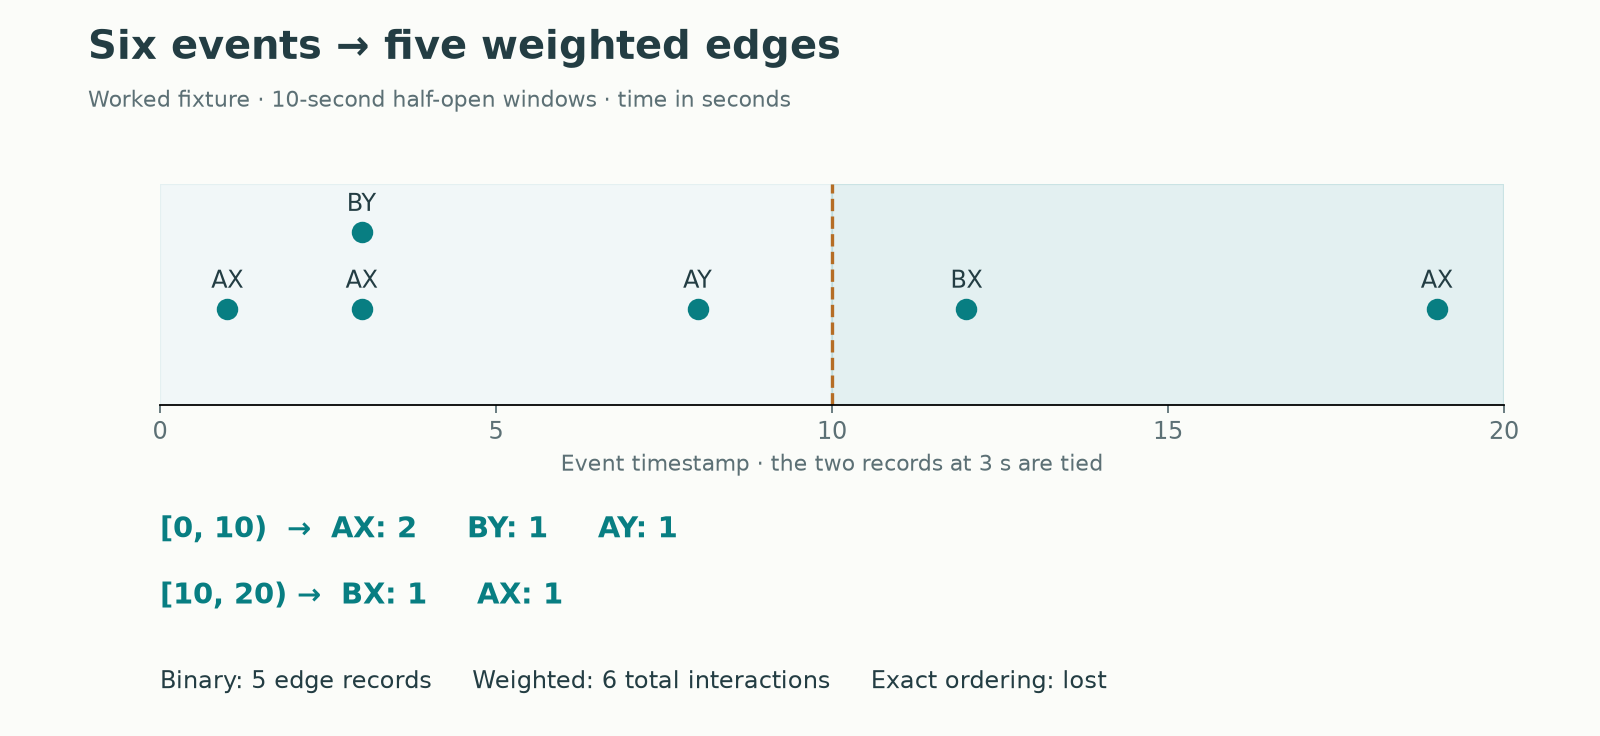<figcaption>Synthetic six-event stream: width 10 yields five binary snapshot edges; count weights sum to six. Timestamp ties remain simultaneous.</figcaption></figure>

**Predict before changing the control:** will increasing the width from 10 to 20 reduce the number of binary edges? Will it change the sum of count weights?

**Portable comparison:** width 10 → five binary records; width 20 → four. Both have weighted total six.

For this stream, width 20 merges the two AX snapshot edges: 5 binary records become 4, while the total count remains 6. Wider windows need not merge anything in another stream. Nested widths make this comparison clean; changing the origin or using nonnested widths can change which events meet.

## 3 · Counts cannot restore a discarded sequence

Keep the same pair counts but exchange the times of two contacts. The resulting snapshot is identical. Yet a time-respecting path—contacts traversed in increasing time order—may disappear. The following is a separate **synthetic directed contact graph**, not the bipartite Wikipedia graph.

<figure class="stream-figure" tabindex="0">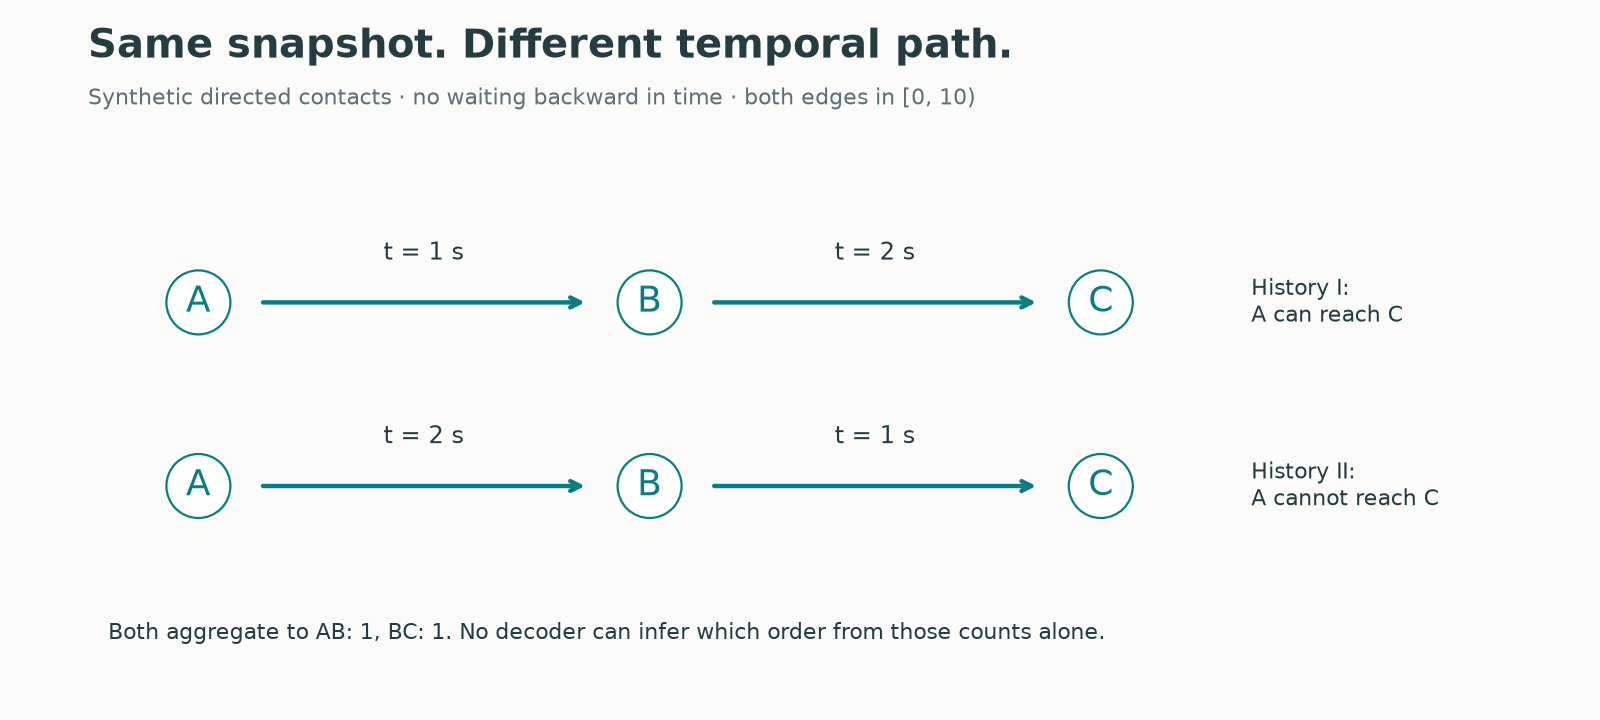<figcaption>Synthetic directed contacts, separate from Wikipedia: identical count-weighted snapshots can conceal opposite temporal reachability.</figcaption></figure>

History I has A→B at 1, then B→C at 2: information starting at A can reach C. History II reverses those times: it cannot. Both weighted snapshots contain AB:1 and BC:1. A downstream model receiving only those counts cannot distinguish the histories. Adding first/last times makes a richer summary, but does not generally recover every repeated event’s timing.

**Predict:** do count weights recover event order, or only preserve interaction totals? Give a counterexample before continuing.

**The right conclusion is task-dependent.** If the question is “how many edits did this pair make in the completed day?”, count weights preserve the answer. If it is “which interaction preceded the complaint?”, those counts may be insufficient. This is an information argument, not evidence that one model has higher AP. A stream encoder can also discard history internally, through sampling, pooling, or memory updates.

## 4 · A window has a publication time

A complete graph for [0,10) contains the event at 8. At a query just before 6, using it would expose the future. Renaming the graph’s timestamp to 0 does not make its contents legal.

We choose **immutable completed windows**. Their earliest permitted release is:

**release = max(window end, latest availability of any constituent event).**

A snapshot is readable when **release ≤ query**. At query 10, [0,10) is legal: every event in it is strictly earlier than 10. An event at 10 belongs to [10,20), which remains unavailable. A late-arriving event can delay the release of its *whole* window.

<figure class="stream-figure" tabindex="0">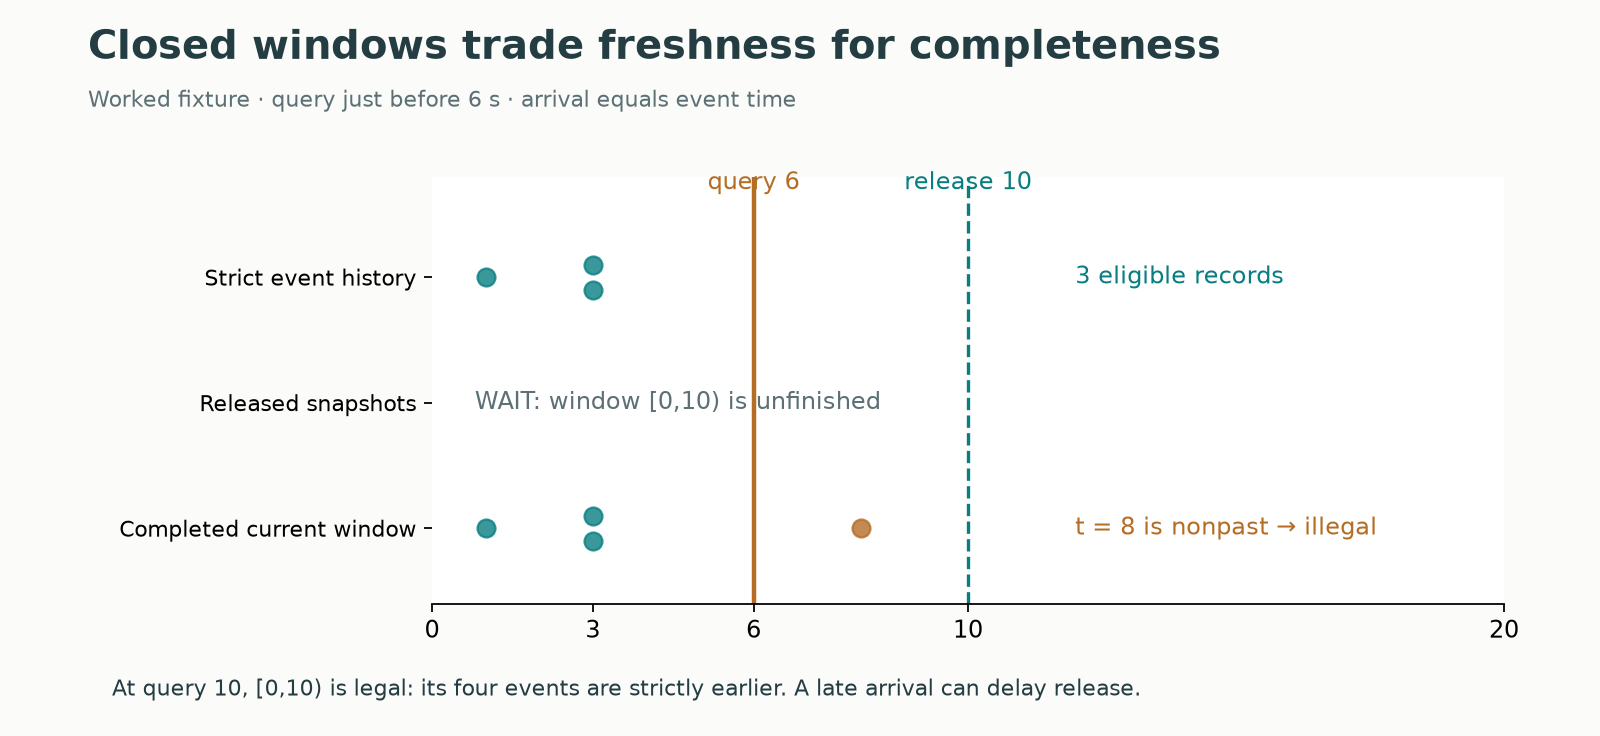<figcaption>Synthetic query at 6 seconds: three eligible records are withheld by closed-window access. Reading the completed current window exposes the event at 8. Vertically separated dots at 3 represent two tied events.</figcaption></figure>

**Portable boundary:** query 9 → no released records; query 10 → four. If the time-8 event arrives at 15, the first window waits until 15.

**Try the boundary.** Move the query from 9 to 10. Four records become readable together. Then set query 12 and enable the delayed arrival: the earlier window must wait until 15. The stream can still use individual records that have already arrived.

Completed-window access is causal but stale: it withholds eligible events in the current unfinished window. Reading the retrospectively completed current window is fresher but can expose the target, timestamp ties, and future records. A third design—an incrementally maintained partial window—is possible, but it is a different representation. It needs versioned “as of query” contents, and its count is not the final window count.

> **Operational limit.** The release formula audits a known finite set of records. In a live service, you cannot infer that no more late events will arrive just by taking the maximum arrival observed so far. You need a documented completeness signal, bounded-delay policy, or revisions. The Wikipedia file supplies no ingestion history. Our measured audit assumes availability = event time; delayed arrivals are synthetic tests.

## 5 · Reproduce the complete representation experiment

The [JODIE authors’ Wikipedia release](https://snap.stanford.edu/jodie/) has **157,474 interactions**, involving **8,227 users and 1,000 pages** in the authenticated bytes used here. We retain endpoint IDs, times, and row identities. The original state labels and 172-dimensional edge features are outside this projection. This audit does not claim that the reduced table reconstructs the entire raw record.

**Declared before execution:** all events; widths 3,600 / 86,400 / 604,800 seconds; origin 0; half-open windows; strict-before event queries; one query per event, including timestamp ties; completed-window release. There is no training, tuning, train/test score, or random-seed uncertainty. These are exact census statistics of this file under these rules.

**Author execution: PASS, all 157,474 events × all three declared widths.**

| Window | Binary edge records | Binary collapse | Hidden strict pairs | Mean wait |
|---|---:|---:|---:|---:|
| Hourly | 64,991 | 58.73% | 17,758,336 | 0.50 h |
| Daily | 39,804 | 74.72% | 407,383,515 | 11.42 h |
| Weekly | 25,695 | 83.68% | 2,727,616,004 | 87.42 h |

Weighted count sums: **157,474 in every condition**. All 4,816 timestamp-tied pairs are excluded from the strict-order count.

| Window | Mean past records withheld / query | Mean nonpast exposure / query | Unreleased events at final query |
|---|---:|---:|---:|
| Hourly | 112.77 | 113.83 | 124 |
| Daily | 2,586.99 | 2,588.05 | 3,651 |
| Weekly | 17,321.06 | 17,322.12 | 12,173 |

These global counts are deterministic; no error bars or confidence intervals are warranted for this fixed-file census. They are not predictive performance estimates.

<figure class="stream-figure" tabindex="0">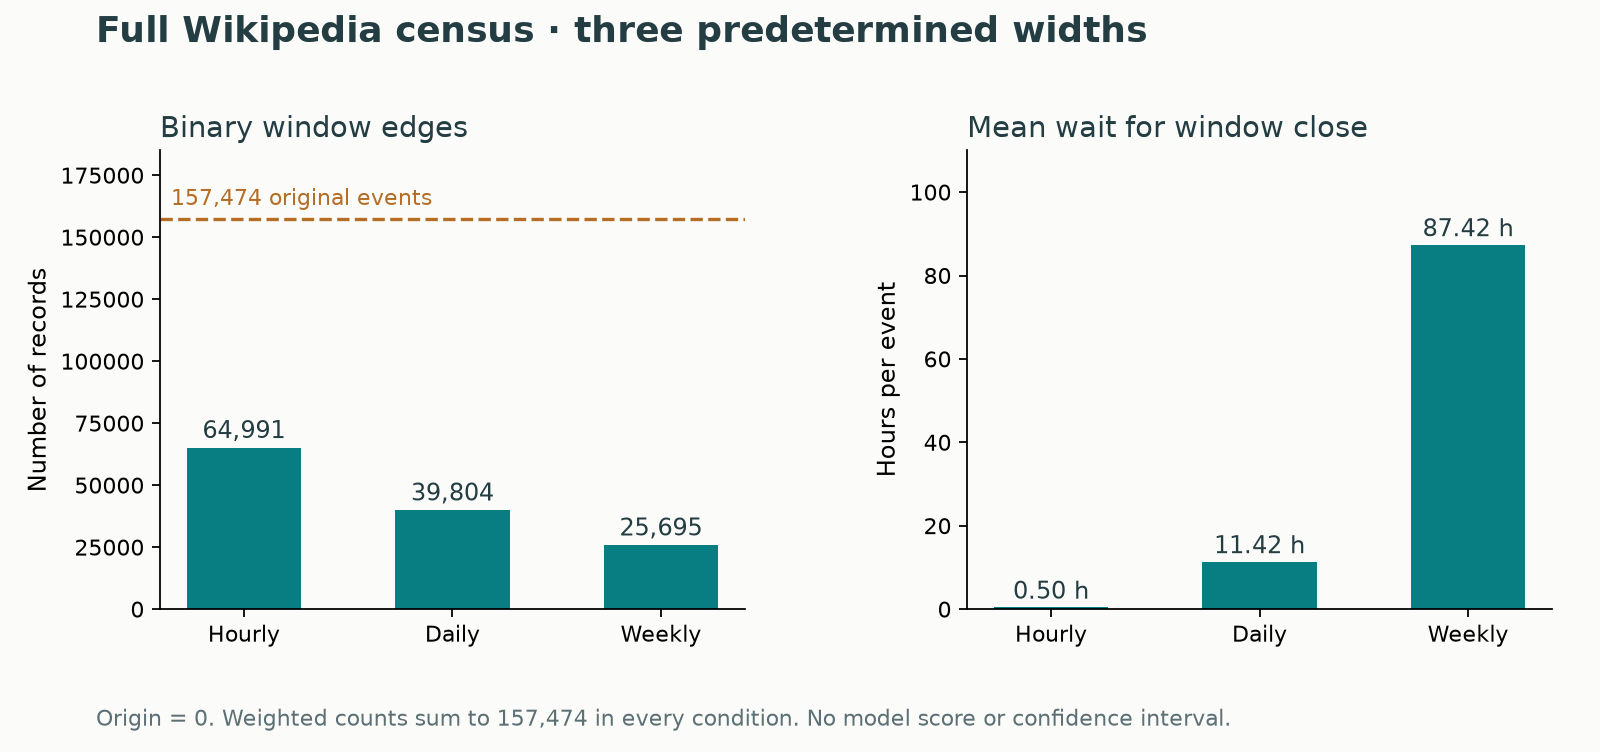<figcaption>Measured full Wikipedia census, not a prediction benchmark. Fixed widths from origin zero; weights preserve the event total. Wait assumes availability equals event time.</figcaption></figure>

**Read the measures carefully.**

- **Binary collapse** = events minus distinct `(window,user,page)` keys. It measures records omitted by the binary projection, not a percentage of all information lost. Count weights preserve multiplicity.
- **Hidden strict pairs** counts pairs of events with distinct times in the same window. Such ordering is not recoverable from count-only snapshots. We count pairs across the entire stream, including unrelated endpoints; this is not a causal-dependency count.
- **Past records withheld per query** counts strictly earlier global-stream records excluded by closed-window access. **Nonpast exposure** counts records at or after the query inside the completed current window. Both are global access diagnostics, not a GNN’s actual sampled inputs.
- **Wait for release** is window end minus event time under the arrival=event assumption. It includes the final partial observation window’s scheduled close; we do not release that window early merely because the file ends.

**An exact identity to explain.** Summed withheld-past counts equal hidden strict pairs. Each pair `(earlier event, later query event)` in one bin contributes once to both. Nonpast exposure minus withheld-past totals equals **N + 2 × tied timestamp pairs**: self-records and simultaneous pairs remain on the nonpast side. This catches implementations that silently order tied timestamps.

The raw file has **152,757 distinct timestamps** and **4,816 unordered pairs tied in time**. We never claim their physical order. Snapshot results agree with an independent SQLite `GROUP BY`; a separate grouped-timestamp walk reconstructs pair counts. All-query release counts are checked independently as well.

**Evidence boundary:** the complete three-condition *course audit* is reproduced. This is not a new reproduction of TGN/JODIE model scores, a full-paper replication, or a measurement of ingestion delays. Source identity and deviations are in the [source manifest](https://avistian.github.io/relational/labs/_sources_l105.json); exact results are in the [audit report](https://avistian.github.io/relational/labs/_analysis_l105_results.json).

## 6 · Build it yourself

[Student notebook](https://avistian.github.io/relational/labs/0105-continuous-time.ipynb) · [Executed solution view](https://avistian.github.io/relational/labs/html/0105-continuous-time.html) · [Solution notebook](https://avistian.github.io/relational/labs/solutions/0105-continuous-time.ipynb) · [Complete reproduction protocol](https://avistian.github.io/relational/labs/l105-reproduction.md)

The notebook is standalone: it includes the canonical implementation in annotated chunks, portable diagrams, immediate checks, and all three full-data conditions. Its default full replay authenticates the original **560 MB** download; an existing matching raw file can be reused. No GPU is needed.

| Live task | Your implementation must decide | Counterexample to pass |
|---|---|---|
| TODO 1: `bin_index` | Half-open boundary and fixed origin | Time 10 moves into bin 1 at width 10 |
| TODO 2: `aggregate_events` | Typed pair grouping, counts, complete-window availability | Two late/early edges in one bin must share its delayed release |
| TODO 3: `visible_snapshot_mask` | Whether the whole snapshot is published | Release at query is legal; release after query is not |

Each function is called by the full-data audit; these are live implementation tasks. Write your predictions before running. Keep the solution closed until you have attempted the checks. After a hint, close it and implement again from memory.

The core release gate is short; the hard part is defining what its timestamp means:

Implement the release gate yourself in TODO 3 below.

## 7 · EXIT: defend a representation

Write 150–250 words comparing two services:

1. A daily report predicts tomorrow’s edit volume after yesterday’s data is declared complete.
2. An online service scores each new interaction immediately before it occurs.

For each, specify the prediction clock, retained information, bin/availability policy, and one counterexample that would invalidate your choice. Explain why weighted snapshots can answer a completed-window count question yet fail a temporal-path question. Cite one measured audit quantity without turning it into an accuracy claim.

**Pass criteria:** all three TODO checks; complete three-width replay; a tie/boundary/late-arrival counterexample; and a defensible written choice. Running the notebook alone does not establish mastery. Status remains **PENDING_WRITTEN_DEFENSE** until your work is reviewed.

**Write your defense before opening the solution.**

**Spacing:** tomorrow, reconstruct the two histories with identical snapshots but different temporal paths without looking. In one week, repeat the argument for purchases or messages.

**Read next:** [TGN §2](https://arxiv.org/html/2006.10637v3#S2), then the [event/snapshot reference card](https://avistian.github.io/relational/reference/event-stream-snapshots.html). Ask the tutor about any unclear boundary, or paste your EXIT defense for review. L106 will define future-edge labels and temporal negatives; L107 will put models on the snapshot representation. Neither should silently change the clock contract established here.

## Implement and test

Predict the expected output before each CHECK. The full-data experiment below calls your functions directly. The reference evidence above is author output, not a claim about your current kernel.

### Imports and immutable data identity

In [ ]:
from pathlib import Path
import hashlib
import urllib.request
import numpy as np

DATA_URL='https://snap.stanford.edu/jodie/wikipedia.csv'
DATA_SHA256='a6b73e09c0d1e5b9db11e7e7aa416f2e87838a745273e0446a79952cf4cfae09'
WIDTHS=(3600,86400,604800)

### PROVIDED: validate the event contract

In [ ]:
def validate_events(events):
    required=('u','v','t','a','e')
    if any(k not in events for k in required):
        raise ValueError('Require u, v, t, a (availability), e (event identity)')
    n=len(events['t'])
    if any(np.asarray(events[k]).shape!=(n,) for k in required):
        raise ValueError('Event columns must be aligned one-dimensional arrays')
    t,a=np.asarray(events['t']),np.asarray(events['a'])
    if not np.isfinite(t).all() or not np.isfinite(a).all() or np.any(a<t):
        raise ValueError('Finite timestamps and availability >= event time required')
    if np.any(np.diff(t)<0):
        raise ValueError('Sort events by time; ties remain simultaneous')
    for k in ('u','v','e'):
        if np.asarray(events[k]).dtype.kind not in 'iu' or np.any(events[k]<0):
            raise ValueError('IDs must be nonnegative integers')
    if len(np.unique(events['e']))!=n:
        raise ValueError('Event identities must be unique; repeated edges are legal')

In [ ]:
# PROVIDED — the teaching example, separate from Wikipedia.
def fixture(t,u=None,v=None,a=None):
    t=np.asarray(t,dtype=float); n=len(t)
    return {'t':t,'a':np.asarray(a if a is not None else t,dtype=float),
            'u':np.asarray(u if u is not None else [0]*n,dtype=np.int64),
            'v':np.asarray(v if v is not None else [0]*n,dtype=np.int64),
            'e':np.arange(n,dtype=np.int64)}
worked=fixture([1,3,3,8,12,19],u=[0,0,1,0,1,0],v=[0,0,1,1,0,0])


### TODO 1: assign half-open time windows

Return int64 window indices for a one-dimensional array. Validate finite positive width, finite origin/times, and t ≥ origin. Use the half-open convention; test exact boundaries, not just mid-window examples.

**Prediction:** write the expected check outputs before implementing.

In [ ]:
def bin_index(times,width,origin=0.0):
    """Return int64 window indices for a one-dimensional array. Validate finite positive width, finite origin/times, and t ≥ origin. Use the half-open convention; test exact boundaries, not just mid-window examples."""
    raise NotImplementedError("Implement bin_index before the CHECK")

### CHECK · bin_index

In [ ]:
np.testing.assert_array_equal(bin_index(np.array([0,9.999,10,20]),10),[0,0,1,2])
np.testing.assert_array_equal(bin_index(np.array([7,17]),10,origin=7),[0,1])
for invalid_width in [0,-1,float('nan')]:
    try: bin_index(np.array([1]),invalid_width)
    except ValueError: pass
    else: raise AssertionError('Reject invalid widths before assigning bins')
print('PASS: exact boundary, nonzero origin, invalid widths')

### TODO 2: preserve multiplicity while aggregating endpoints

Return aligned arrays bin/u/v/count/start/end/first/last/release sorted by (bin,u,v). Call validate_events and your bin_index. Use np.unique on structured keys plus reduction operations. first/last are audit metadata. For release, reduce availability over each entire window, then map that window maximum to every edge in it. Handle empty input.

**Prediction:** write the expected check outputs before implementing.

In [ ]:
def aggregate_events(events,width,origin=0.0):
    """Return aligned arrays bin/u/v/count/start/end/first/last/release sorted by (bin,u,v). Call validate_events and your bin_index. Use np.unique on structured keys plus reduction operations. first/last are audit metadata. For release, reduce availability over each entire window, then map that window maximum to every edge in it. Handle empty input."""
    raise NotImplementedError("Implement aggregate_events before the CHECK")

### CHECK · aggregate_events

In [ ]:
snap=aggregate_events(worked,10)
np.testing.assert_array_equal(snap['bin'],[0,0,0,1,1])
np.testing.assert_array_equal(snap['u'],[0,0,1,0,1])
np.testing.assert_array_equal(snap['v'],[0,1,1,0,0])
np.testing.assert_array_equal(snap['count'],[2,1,1,1,1])
assert snap['count'].sum()==6
late=aggregate_events(fixture([1,2],u=[0,1],a=[1,12]),10)
np.testing.assert_array_equal(late['release'],[12,12])
assert len(aggregate_events(fixture([]),10)['count'])==0
assert len(aggregate_events(fixture([1,2],u=[0,1],v=[1,0]),10)['count'])==2
print('PASS: typed endpoints, count conservation, empty stream, whole-window late arrival')

### TODO 3: enforce the snapshot's publication boundary

Return one boolean per snapshot edge: is its complete window published by the query? Reject a nonfinite query. Explain why equality is allowed here while the event-history rule remains strict.

**Prediction:** write the expected check outputs before implementing.

In [ ]:
def visible_snapshot_mask(snapshots,query):
    """Return one boolean per snapshot edge: is its complete window published by the query? Reject a nonfinite query. Explain why equality is allowed here while the event-history rule remains strict."""
    raise NotImplementedError("Implement visible_snapshot_mask before the CHECK")

### CHECK · visible_snapshot_mask

In [ ]:
snap=aggregate_events(worked,10)
assert snap['count'][visible_snapshot_mask(snap,9)].sum()==0
assert snap['count'][visible_snapshot_mask(snap,10)].sum()==4
assert snap['count'][visible_snapshot_mask(snap,20)].sum()==6
late=aggregate_events(fixture([1,2],u=[0,1],a=[1,12]),10)
assert not visible_snapshot_mask(late,10).any()
assert visible_snapshot_mask(late,12).all()
assert not visible_snapshot_mask(aggregate_events(fixture([21]),10),29).any()
print('PASS: publication boundary, delayed window, final partial bin')

### PROVIDED: compute the complete representation audit

In [ ]:
def choose2(counts):
    c=np.asarray(counts,dtype=np.int64)
    return int(np.sum(c*(c-1)//2))


def audit_stream(events,width,origin=0.0):
    """All event timestamps are queries, including repeats; no labels or training.

    Access counts concern the entire stream, not a node-local model sampler.
    The real-data audit assumes a=t. Delayed-arrival behavior is tested separately.
    """
    snapshots=aggregate_events(events,width,origin)
    t=np.asarray(events['t']);n=len(t)
    if not np.array_equal(events['a'],t):
        raise ValueError('Global access audit requires availability == event time')
    b=bin_index(t,width,origin);start=origin+b*width;end=start+width
    _,bin_counts=np.unique(b,return_counts=True)
    _,tie_counts=np.unique(t,return_counts=True)
    ties=choose2(tie_counts)
    # searchsorted(left) excludes the query's entire tie group.
    strict_history=np.searchsorted(t,t,side='left')
    before_window=np.searchsorted(t,start,side='left')
    through_window=np.searchsorted(t,end,side='left')
    withheld=strict_history-before_window
    nonpast=through_window-strict_history
    delay=end-t
    return {'width_seconds':int(width),'origin_seconds':float(origin),'events':n,
            'snapshot_edges':len(snapshots['count']),
            'collapsed_events':n-len(snapshots['count']),
            'collapsed_percent':100*(n-len(snapshots['count']))/n if n else 0.0,
            'weighted_count_sum':int(snapshots['count'].sum()),
            'occupied_windows':len(bin_counts),
            'total_windows':int(b.max()+1) if n else 0,
            'empty_windows':int(b.max()+1)-len(bin_counts) if n else 0,
            'tied_timestamp_pairs':ties,
            'hidden_strict_pairs':choose2(bin_counts)-ties,
            'withheld_past_sum':int(withheld.sum()),
            'nonpast_exposure_sum':int(nonpast.sum()),
            'queries_with_withheld_past':int(np.count_nonzero(withheld)),
            'queries_with_nonpast_exposure':int(np.count_nonzero(nonpast)),
            'mean_withheld_past':float(withheld.mean()) if n else 0.0,
            'mean_nonpast_exposure':float(nonpast.mean()) if n else 0.0,
            'delay_mean_seconds':float(delay.mean()) if n else 0.0,
            'delay_p95_seconds':float(np.quantile(delay,.95)) if n else 0.0,
            'delay_max_seconds':float(delay.max()) if n else 0.0,
            'unreleased_events_at_last_query':int(snapshots['count'][~visible_snapshot_mask(snapshots,float(t[-1]))].sum()) if n else 0}

### PROVIDED: authenticate original bytes and parse the event projection

In [ ]:
def load_wikipedia(path):
    """Load only event identity/endpoints/time. Features and labels are excluded.

    Download is ~560 MB. The CSV header describes its variable-width trailing
    features; parsing only columns 0..2 avoids treating that header as a schema.
    No processed cache is trusted. The complete raw file is authenticated each run.
    """
    path=Path(path);path.parent.mkdir(parents=True,exist_ok=True)
    if not path.exists():
        temp=path.with_suffix('.download')
        urllib.request.urlretrieve(DATA_URL,temp)
        with temp.open('rb') as f:
            if hashlib.file_digest(f,'sha256').hexdigest()!=DATA_SHA256:
                temp.unlink();raise ValueError('Downloaded dataset checksum mismatch')
        temp.replace(path)
    with path.open('rb') as f:
        actual=hashlib.file_digest(f,'sha256').hexdigest()
    if actual!=DATA_SHA256:
        raise ValueError('Raw dataset checksum mismatch; do not reuse these bytes')
    raw=np.loadtxt(path,delimiter=',',skiprows=1,usecols=(0,1,2),dtype=np.float64)
    if not np.equal(raw[:,:2],np.floor(raw[:,:2])).all():
        raise ValueError('Raw endpoint IDs are not integers')
    events={'u':raw[:,0].astype(np.int64),'v':raw[:,1].astype(np.int64),
            't':raw[:,2],'a':raw[:,2].copy(),'e':np.arange(len(raw),dtype=np.int64)}
    validate_events(events)
    if len(raw)!=157474 or len(np.unique(events['u']))!=8227 or len(np.unique(events['v']))!=1000:
        raise ValueError('Unexpected Wikipedia release population')
    return events

## RUN · the complete experiment

No hidden training or sampled data. Three widths, every raw record, exact pinned bytes. If a CHECK failed, fix it before downloading. This run does not require the course repository or any saved model.

In [ ]:
# PROVIDED — complete raw-data replay. About 560 MB on first download.
# You may place the authenticated raw file here before running.
RAW_PATH=Path('l105-data/wikipedia.csv')
events=load_wikipedia(RAW_PATH)
results=[audit_stream(events,width) for width in WIDTHS]
EXPECTED=[{'width_seconds': 3600, 'origin_seconds': 0.0, 'events': 157474, 'snapshot_edges': 64991, 'collapsed_events': 92483, 'collapsed_percent': 58.72906003530741, 'weighted_count_sum': 157474, 'occupied_windows': 744, 'total_windows': 744, 'empty_windows': 0, 'tied_timestamp_pairs': 4816, 'hidden_strict_pairs': 17758336, 'withheld_past_sum': 17758336, 'nonpast_exposure_sum': 17925442, 'queries_with_withheld_past': 156716, 'queries_with_nonpast_exposure': 157474, 'mean_withheld_past': 112.76995567522258, 'mean_nonpast_exposure': 113.83112132796525, 'delay_mean_seconds': 1800.6045505924787, 'delay_p95_seconds': 3418.0, 'delay_max_seconds': 3600.0, 'unreleased_events_at_last_query': 124}, {'width_seconds': 86400, 'origin_seconds': 0.0, 'events': 157474, 'snapshot_edges': 39804, 'collapsed_events': 117670, 'collapsed_percent': 74.72344641020105, 'weighted_count_sum': 157474, 'occupied_windows': 31, 'total_windows': 31, 'empty_windows': 0, 'tied_timestamp_pairs': 4816, 'hidden_strict_pairs': 407383515, 'withheld_past_sum': 407383515, 'nonpast_exposure_sum': 407550621, 'queries_with_withheld_past': 157442, 'queries_with_nonpast_exposure': 157474, 'mean_withheld_past': 2586.989058511246, 'mean_nonpast_exposure': 2588.050224163989, 'delay_mean_seconds': 41104.761427283236, 'delay_p95_seconds': 82417.0, 'delay_max_seconds': 86400.0, 'unreleased_events_at_last_query': 3651}, {'width_seconds': 604800, 'origin_seconds': 0.0, 'events': 157474, 'snapshot_edges': 25695, 'collapsed_events': 131779, 'collapsed_percent': 83.68302068912963, 'weighted_count_sum': 157474, 'occupied_windows': 5, 'total_windows': 5, 'empty_windows': 0, 'tied_timestamp_pairs': 4816, 'hidden_strict_pairs': 2727616004, 'withheld_past_sum': 2727616004, 'nonpast_exposure_sum': 2727783110, 'queries_with_withheld_past': 157469, 'queries_with_nonpast_exposure': 157474, 'mean_withheld_past': 17321.05619975361, 'mean_nonpast_exposure': 17322.117365406353, 'delay_mean_seconds': 314727.98811867356, 'delay_p95_seconds': 575291.0, 'delay_max_seconds': 604800.0, 'unreleased_events_at_last_query': 12173}]
assert results==EXPECTED, 'Full-data results differ: inspect protocol and live TODO functions'
from IPython.display import HTML, display
rows=''.join(f"<tr><td>{r['width_seconds']}</td><td>{r['snapshot_edges']:,}</td><td>{r['collapsed_percent']:.2f}%</td><td>{r['hidden_strict_pairs']:,}</td><td>{r['delay_mean_seconds']/3600:.2f}</td></tr>" for r in results)
display(HTML('<table><tr><th>Window seconds</th><th>Binary edges</th><th>Collapse</th><th>Hidden strict pairs</th><th>Mean wait hours</th></tr>'+rows+'</table>'))
import json
Path('l105-fresh.json').write_text(json.dumps(results,indent=2)+'\n')
print('PASS: full file, all three conditions, exact author-report equality')


## CHECK · independent reconstruction

A second algorithm should reach the same answer. SQLite handles endpoint grouping; a timestamp walk counts pairs without the vectorized searchsorted implementation.

In [ ]:
# PROVIDED — independently group the complete projected stream in SQLite.
import sqlite3
from collections import Counter,defaultdict
conn=sqlite3.connect(':memory:')
conn.execute('CREATE TABLE events(u INTEGER,v INTEGER,t REAL)')
conn.executemany('INSERT INTO events VALUES(?,?,?)',
    ((int(u),int(v),float(t)) for u,v,t in zip(events['u'],events['v'],events['t'])))
for width,measured in zip(WIDTHS,results):
    oracle=conn.execute('SELECT CAST(t / ? AS INTEGER),u,v,COUNT(*),MIN(t),MAX(t) FROM events GROUP BY 1,2,3 ORDER BY 1,2,3',(width,)).fetchall()
    snap=aggregate_events(events,width)
    np.testing.assert_array_equal(np.column_stack([snap[k] for k in ['bin','u','v','count','first','last']]),np.array(oracle))
    buckets=defaultdict(Counter)
    for t in events['t']: buckets[int(t//width)][float(t)]+=1
    past_pairs=nonpast=0
    for times in buckets.values():
        previous=0; total=sum(times.values())
        for t,count in sorted(times.items()):
            past_pairs+=previous*count; nonpast+=(total-previous)*count; previous+=count
    assert measured['hidden_strict_pairs']==measured['withheld_past_sum']==past_pairs
    assert measured['nonpast_exposure_sum']==nonpast
    assert nonpast-past_pairs==len(events['t'])+2*measured['tied_timestamp_pairs']
conn.close()
print('PASS: all snapshot rows and pair totals reconstructed independently')


## EXIT · submit evidence

Submit your three live functions, the complete result table, and the 150–250 word representation defense described above. Add a new boundary fixture of your own. A matching report alone is not evidence of mastery.

**Source and protocol:** [reproduction ledger](https://avistian.github.io/relational/labs/l105-reproduction.md).

**Published model results:** NOT_APPLICABLE to this course audit. Live Colab: NOT_CHECKED. No model fitting or upstream score reproduction occurred here.